# 02 — Text Preprocessing

Apply the full NLP pipeline: cleaning, tokenisation, and sequence padding.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import pandas as pd
import config
from src.preprocessing import load_raw_data, clean_text, preprocess_dataframe

## 1. Load raw data

In [2]:
df_raw = load_raw_data()
df_raw.head()

2026-06-30 03:06:57 | INFO | preprocessing | Loading dataset from c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\dataset\spam.csv
2026-06-30 03:06:57 | INFO | preprocessing | Loaded 5169 rows  |  spam=653  ham=4516


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Demonstrate cleaning on sample messages

In [3]:
samples = [
    'FREE entry in 2 a wkly comp to WIN FA Cup final tkts 21st May 2005!',
    'Hey, are you coming to the party tonight? Let me know!',
    'URGENT! You have won a £1000 gift card. Call 09063442151 now!',
]
for s in samples:
    print(f'ORIGINAL : {s}')
    print(f'CLEANED  : {clean_text(s)}')
    print()

ORIGINAL : FREE entry in 2 a wkly comp to WIN FA Cup final tkts 21st May 2005!
CLEANED  : free entri wkli comp win fa cup final tkt st may

ORIGINAL : Hey, are you coming to the party tonight? Let me know!
CLEANED  : hey come parti tonight let know

ORIGINAL : URGENT! You have won a £1000 gift card. Call 09063442151 now!
CLEANED  : urgent £ gift card call



## 3. Full preprocessing

In [4]:
df = preprocess_dataframe(df_raw)
print(df[['v2','label','cleaned_text']].head())
print(f"\nNull cleaned rows: {df['cleaned_text'].isna().sum()}")
print(f"Empty cleaned rows: {(df['cleaned_text']=='').sum()}")

2026-06-30 03:06:57 | INFO | preprocessing | Encoding labels …
2026-06-30 03:06:57 | INFO | preprocessing | Cleaning text (this may take a moment) …
2026-06-30 03:06:58 | INFO | preprocessing | Preprocessing complete.


                                                  v2  label  \
0  Go until jurong point, crazy.. Available only ...      0   
1                      Ok lar... Joking wif u oni...      0   
2  Free entry in 2 a wkly comp to win FA Cup fina...      1   
3  U dun say so early hor... U c already then say...      0   
4  Nah I don't think he goes to usf, he lives aro...      0   

                                        cleaned_text  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri wkli comp win fa cup final tkt st m...  
3                u dun say earli hor u c alreadi say  
4          nah dont think goe usf live around though  

Null cleaned rows: 0
Empty cleaned rows: 6


## 4. Tokenisation

In [5]:
from sklearn.model_selection import train_test_split
from src.tokenizer_utils import build_tokenizer, texts_to_padded_sequences, get_vocab_size

X = df['cleaned_text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
tokenizer = build_tokenizer(X_train.tolist())

X_train_seq = texts_to_padded_sequences(tokenizer, X_train.tolist())
X_test_seq  = texts_to_padded_sequences(tokenizer, X_test.tolist())

print("X_train shape:", X_train_seq.shape)
print("X_test shape :", X_test_seq.shape)
print("Vocab size   :", get_vocab_size(tokenizer))

c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.10) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
2026-06-30 03:07:07 | INFO | tokenizer_utils | Fitting tokenizer on 4135 texts  (vocab_size=10000, oov='<OOV>') …
2026-06-30 03:07:07 | INFO | tokenizer_utils | Vocabulary size (incl. OOV+PAD): 6074


X_train shape: (4135, 150)
X_test shape : (1034, 150)
Vocab size   : 6074


## 5. Sequence length distribution

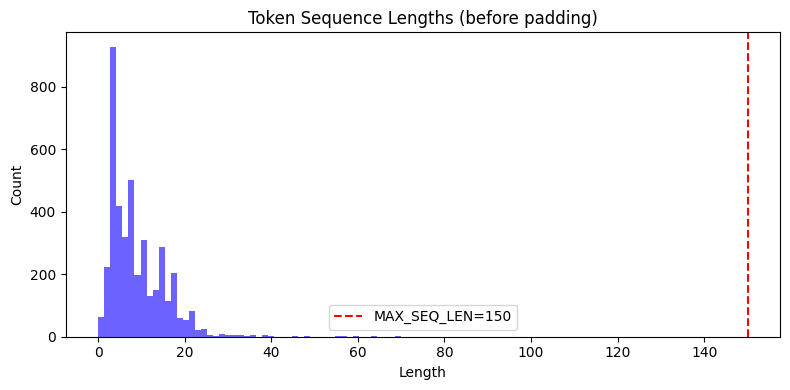

95th percentile: 20


In [6]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
lengths = [len(tokenizer.texts_to_sequences([t])[0]) for t in X_train]
plt.figure(figsize=(8,4))
plt.hist(lengths, bins=50, color='#6c63ff', edgecolor='none')
plt.axvline(config.MAX_SEQ_LEN, color='red', linestyle='--', label=f'MAX_SEQ_LEN={config.MAX_SEQ_LEN}')
plt.title('Token Sequence Lengths (before padding)')
plt.xlabel('Length'); plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../saved_plots/sequence_lengths.png', dpi=150)
plt.show()
print(f"95th percentile: {sorted(lengths)[int(len(lengths)*0.95)]}")